In [1]:
# Import library yang dibutuhkan
# pandas digunakan untuk membaca dan mengolah data
# matplotlib digunakan untuk visualisasi
# pathlib digunakan untuk mengatur path folder/file

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Menentukan lokasi folder project
# PROCESSED_DIR = folder tempat master dataset disimpan
# FIGURES_DIR = folder untuk menyimpan grafik hasil ARIMA

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Processed directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)

Processed directory: c:\Users\Project\skripsi\inflation-forecast-final\data\processed
Figures directory: c:\Users\Project\skripsi\inflation-forecast-final\reports\figures


In [3]:
# Membaca master dataset hasil merge

master_df = pd.read_csv(PROCESSED_DIR / "master_dataset.csv")

master_df.head()

,date,inflation,bi_rate,exchange_rate,oil_price
0,2010-01-01,0.84,6.5,9270.000000,76.167368
1,2010-02-01,-0.08,6.5,9326.250000,73.752105
2,2010-03-01,-0.14,6.5,9161.086957,78.827391
3,2010-04-01,0.15,6.5,9026.318182,84.817619
4,2010-05-01,0.29,6.5,9160.238095,75.945500


In [4]:
# Untuk model ARIMA, kita hanya menggunakan variabel inflasi
# ARIMA adalah model univariate, jadi tidak menggunakan variabel eksternal

inflation_df = master_df[["date", "inflation"]].copy()

inflation_df["date"] = pd.to_datetime(inflation_df["date"])

inflation_df.head()

,date,inflation
0,2010-01-01,0.84
1,2010-02-01,-0.08
2,2010-03-01,-0.14
3,2010-04-01,0.15
4,2010-05-01,0.29


In [5]:
# Mengubah kolom date menjadi index
# Ini penting karena ARIMA bekerja dengan data time series

inflation_df = inflation_df.set_index("date")

# Mengatur frekuensi data menjadi bulanan dengan awal bulan
# MS = Month Start

inflation_df = inflation_df.asfreq("MS")

inflation_df.head()

,inflation
date,
2010-01-01,0.84
2010-02-01,-0.08
2010-03-01,-0.14
2010-04-01,0.15
2010-05-01,0.29


In [6]:
# Mengecek informasi dataset inflasi

inflation_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 192 entries, 2010-01-01 to 2025-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   inflation  192 non-null    float64
dtypes: float64(1)
memory usage: 3.0 KB


In [7]:
# Mengecek ukuran data inflasi

inflation_df.shape

(192, 1)

In [8]:
# Mengecek missing value

inflation_df.isnull().sum()

inflation    0
dtype: int64

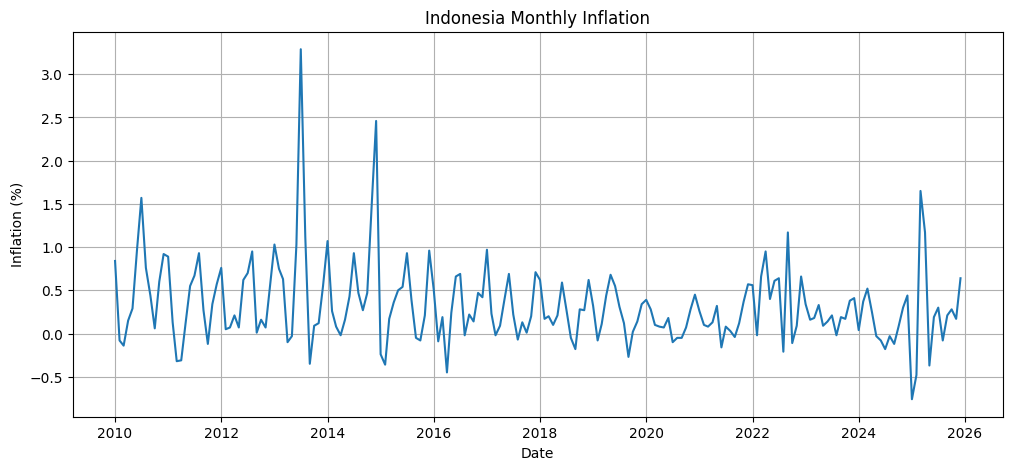

In [9]:
# Visualisasi data inflasi bulanan Indonesia
# Tujuannya untuk melihat pola awal sebelum modeling ARIMA

plt.figure(figsize=(12, 5))
plt.plot(inflation_df.index, inflation_df["inflation"])
plt.title("Indonesia Monthly Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.grid(True)
plt.show()

In [10]:
# Membagi data menjadi train dan test
# Train digunakan untuk melatih model
# Test digunakan untuk mengevaluasi hasil forecasting

train = inflation_df.loc["2010-01-01":"2023-12-01"]
test = inflation_df.loc["2024-01-01":"2025-12-01"]

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (168, 1)
Test shape : (24, 1)


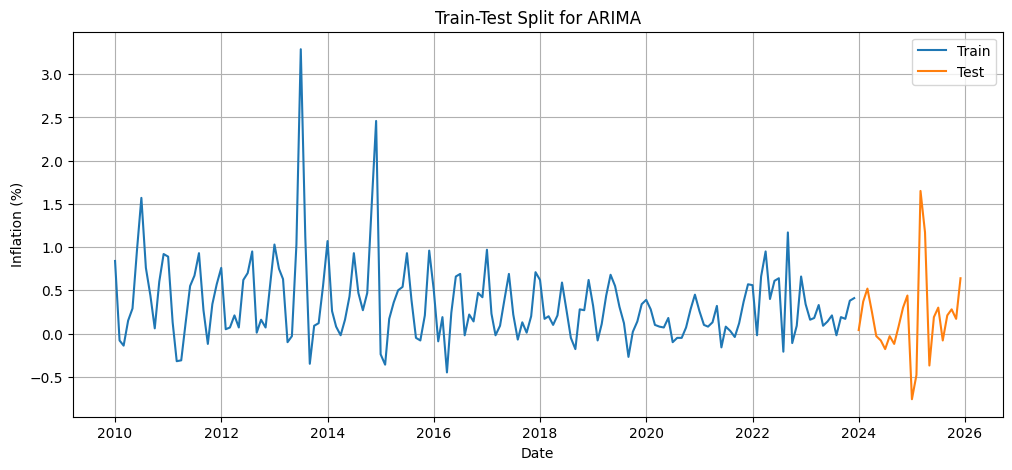

In [11]:
# Visualisasi pembagian train dan test

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["inflation"], label="Train")
plt.plot(test.index, test["inflation"], label="Test")
plt.title("Train-Test Split for ARIMA")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Import Augmented Dickey-Fuller Test
# ADF Test digunakan untuk mengecek apakah data time series sudah stationer atau belum

from statsmodels.tsa.stattools import adfuller

In [13]:
# Melakukan ADF Test pada data inflasi train
# Kita hanya menggunakan data train agar proses modeling tidak melihat data test

adf_result = adfuller(train["inflation"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -3.8567633767595955
p-value: 0.0023771195955449636
Critical Values:
1%: -3.471374345647024
5%: -2.8795521079291966
10%: -2.5763733302850174


In [14]:
# Membuat interpretasi otomatis berdasarkan p-value

p_value = adf_result[1]

if p_value < 0.05:
    print("Data train inflasi stationer.")
    print("Kemungkinan nilai d pada ARIMA = 0")
else:
    print("Data train inflasi belum stationer.")
    print("Perlu dilakukan differencing.")
    print("Kemungkinan nilai d pada ARIMA = 1")

Data train inflasi stationer.
Kemungkinan nilai d pada ARIMA = 0


In [15]:
# Import plot ACF dan PACF
# ACF digunakan untuk membantu melihat kandidat nilai q
# PACF digunakan untuk membantu melihat kandidat nilai p

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1000x500 with 0 Axes>

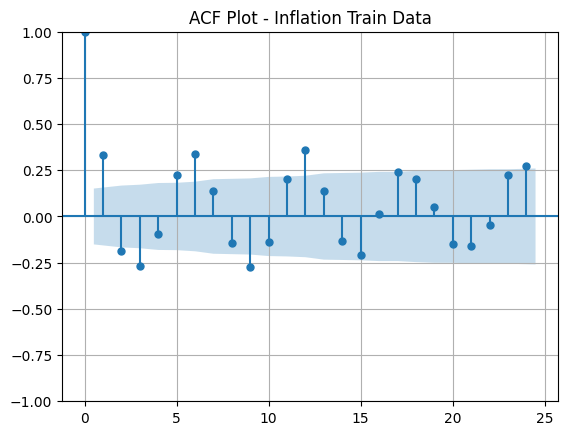

In [16]:
# Membuat plot ACF untuk data train inflasi
# ACF membantu melihat hubungan inflasi saat ini dengan lag sebelumnya
# Plot ini dapat membantu menentukan kandidat nilai q pada ARIMA

plt.figure(figsize=(10, 5))
plot_acf(train["inflation"], lags=24)
plt.title("ACF Plot - Inflation Train Data")
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

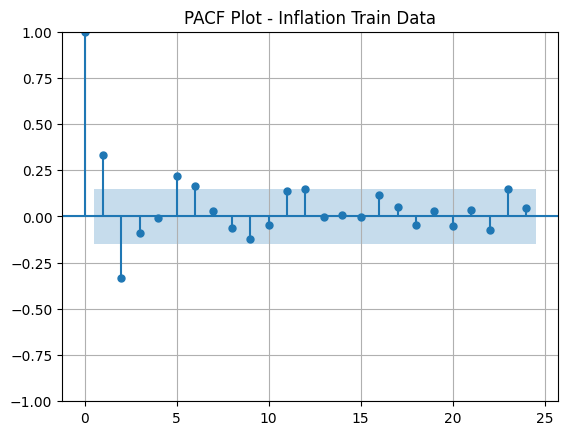

In [17]:
# Membuat plot PACF untuk data train inflasi
# PACF membantu melihat hubungan langsung antara inflasi saat ini dengan lag sebelumnya
# Plot ini dapat membantu menentukan kandidat nilai p pada ARIMA

plt.figure(figsize=(10, 5))
plot_pacf(train["inflation"], lags=24, method="ywm")
plt.title("PACF Plot - Inflation Train Data")
plt.grid(True)
plt.show()

In [18]:
# Import model ARIMA
# ARIMA digunakan sebagai baseline model karena hanya memakai data inflasi historis

from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

In [20]:
# Menentukan beberapa kandidat model ARIMA
# Karena ADF menunjukkan data stationer, nilai d = 0
# Kandidat p dan q dipilih berdasarkan pola ACF dan PACF

candidate_orders = [
    (1, 0, 0),
    (2, 0, 0),
    (0, 0, 1),
    (0, 0, 2),
    (1, 0, 1),
    (2, 0, 1),
    (1, 0, 2),
    (2, 0, 2),
    (3, 0, 1),
    (3, 0, 2)
]

arima_results = []

for order in candidate_orders:
    try:
        model = ARIMA(train["inflation"], order=order)
        fitted_model = model.fit()

        arima_results.append({
            "order": order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic
        })

    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

In [21]:
# Mengubah hasil evaluasi kandidat model menjadi DataFrame
# AIC dan BIC yang lebih kecil menunjukkan model yang lebih baik secara statistik

arima_results_df = pd.DataFrame(arima_results)

arima_results_df = arima_results_df.sort_values(by="AIC")

arima_results_df

,order,AIC,BIC
9,"(3, 0, 2)",162.859753,184.727501
7,"(2, 0, 2)",176.809735,195.553519
1,"(2, 0, 0)",183.100724,195.596580
5,"(2, 0, 1)",184.028796,199.648616
8,"(3, 0, 1)",185.741730,204.485514
2,"(0, 0, 1)",189.622898,198.994790
6,"(1, 0, 2)",190.779644,206.399464
3,"(0, 0, 2)",191.255211,203.751067
4,"(1, 0, 1)",191.454003,203.949859
0,"(1, 0, 0)",201.687623,211.059515


In [22]:
# Membuat model ARIMA terbaik berdasarkan hasil AIC dan BIC
# Model yang dipilih adalah ARIMA(3, 0, 2)
# d = 0 karena hasil ADF Test menunjukkan data train sudah stationer

best_arima_order = (3, 0, 2)

arima_model = ARIMA(
    train["inflation"],
    order=best_arima_order
)

arima_fitted = arima_model.fit()

arima_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              inflation   No. Observations:                  168
Model:                 ARIMA(3, 0, 2)   Log Likelihood                 -74.430
Date:                Mon, 15 Jun 2026   AIC                            162.860
Time:                        12:48:15   BIC                            184.728
Sample:                    01-01-2010   HQIC                           171.735
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3432      0.057      6.059      0.000       0.232       0.454
ar.L1          1.3230      0.059     22.317      0.000       1.207       1.439
ar.L2         -1.3246      0.053    -24.793      0.000      -1.429      -1.220
ar.L3          0.3318      0.053      6.219      0.000       0.227       0.436
ma.L1         -1.0445      0.041    -25.666      0.000      -1.124      -0.965
ma.L2          0.9766      0.059     16.562      0.000       0.861       1.092
sigma2         0.1376      0.010     13.914      0.000       0.118       0.157
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):               791.47
Prob(Q):                              0.70   Prob(JB):                         0.00
Heteroskedasticity (H):               0.45   Skew:                             1.50
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
# Melakukan forecasting sebanyak jumlah data test
# Data test memiliki periode 2024-2025 atau 24 bulan

forecast_steps = len(test)

arima_forecast = arima_fitted.forecast(
    steps=forecast_steps
)

# Menyesuaikan index forecast dengan index data test
# Agar actual dan forecast bisa dibandingkan pada tanggal yang sama

arima_forecast = pd.Series(
    arima_forecast.values,
    index=test.index,
    name="arima_forecast"
)

arima_forecast.head()

date
2024-01-01    0.387006
2024-02-01    0.338247
2024-03-01    0.300788
2024-04-01    0.308186
2024-05-01    0.351413
Freq: MS, Name: arima_forecast, dtype: float64

In [24]:
# Membuat tabel perbandingan antara nilai aktual dan hasil forecast ARIMA

arima_result_df = pd.DataFrame({
    "actual": test["inflation"],
    "forecast": arima_forecast
})

arima_result_df.head()

,actual,forecast
date,,
2024-01-01,0.04,0.387006
2024-02-01,0.37,0.338247
2024-03-01,0.52,0.300788
2024-04-01,0.25,0.308186
2024-05-01,-0.03,0.351413


In [25]:
# Melihat beberapa baris akhir hasil forecast

arima_result_df.tail()

,actual,forecast
date,,
2025-08-01,-0.08,0.332447
2025-09-01,0.21,0.300884
2025-10-01,0.28,0.312029
2025-11-01,0.17,0.354446
2025-12-01,0.64,0.385326


In [26]:
# Import metrics untuk evaluasi model

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [27]:
# Menghitung MAE dan RMSE
# MAE menunjukkan rata-rata kesalahan absolut
# RMSE memberikan penalti lebih besar pada error yang besar

arima_mae = mean_absolute_error(
    arima_result_df["actual"],
    arima_result_df["forecast"]
)

arima_rmse = np.sqrt(
    mean_squared_error(
        arima_result_df["actual"],
        arima_result_df["forecast"]
    )
)

print("ARIMA Order:", best_arima_order)
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)

ARIMA Order: (3, 0, 2)
MAE: 0.38789737557204357
RMSE: 0.5233306773226387


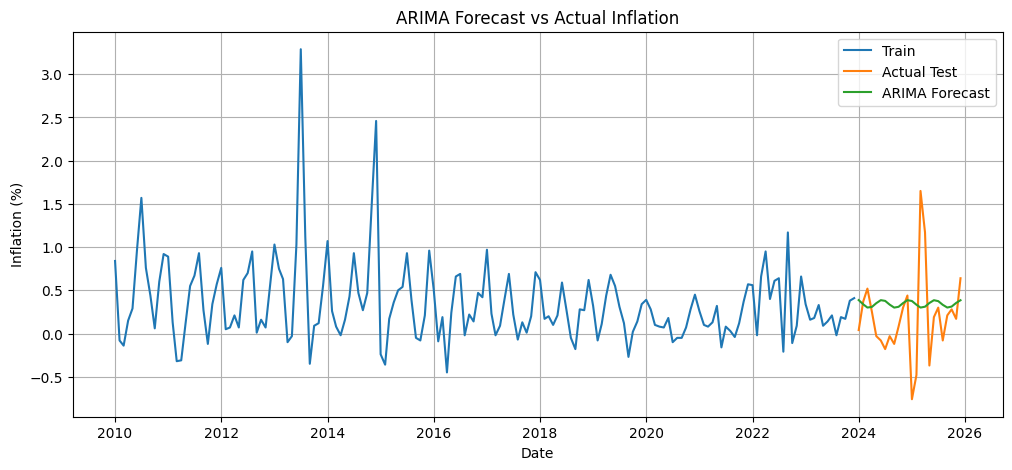

In [28]:
# Visualisasi perbandingan data aktual dan hasil forecast ARIMA

plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["inflation"],
    label="Train"
)

plt.plot(
    test.index,
    test["inflation"],
    label="Actual Test"
)

plt.plot(
    arima_forecast.index,
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.grid(True)
plt.show()

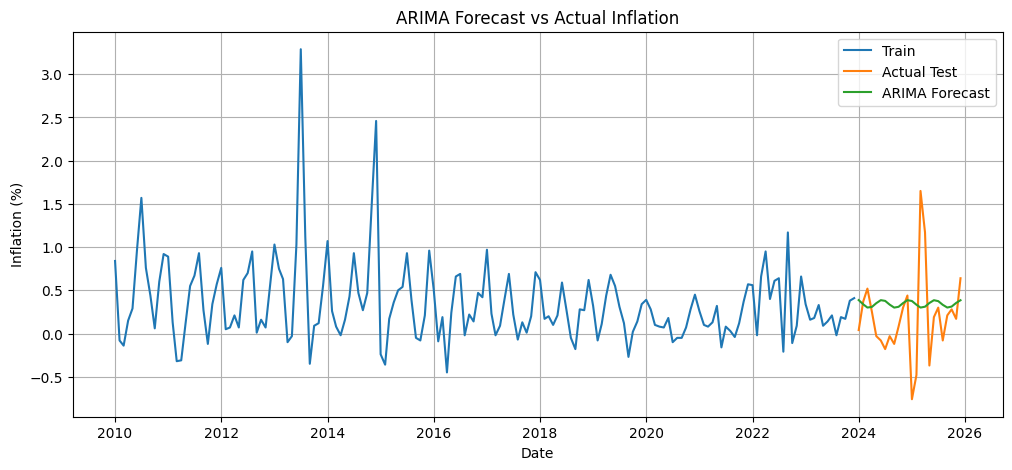

In [29]:
# Menyimpan grafik hasil forecast ARIMA ke folder reports/figures

plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["inflation"],
    label="Train"
)

plt.plot(
    test.index,
    test["inflation"],
    label="Actual Test"
)

plt.plot(
    arima_forecast.index,
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.grid(True)

plt.savefig(
    FIGURES_DIR / "arima_forecast_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Membuat folder untuk menyimpan hasil evaluasi model
# Folder ini akan dipakai untuk menyimpan forecast dan metrics dari ARIMA, SARIMAX, dan XGBoost

RESULTS_DIR = BASE_DIR / "reports" / "model_results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Model results directory:", RESULTS_DIR)

Model results directory: c:\Users\Project\skripsi\inflation-forecast-final\reports\model_results


In [31]:
# Menyimpan hasil actual vs forecast ARIMA
# File ini berguna untuk analisis lanjutan dan perbandingan antar model

arima_forecast_results = arima_result_df.reset_index()

arima_forecast_results["model"] = "ARIMA"
arima_forecast_results["order"] = str(best_arima_order)

arima_forecast_results.to_csv(
    RESULTS_DIR / "arima_forecast_results.csv",
    index=False
)

arima_forecast_results.head()

,date,actual,forecast,model,order
0,2024-01-01,0.04,0.387006,ARIMA,"(3, 0, 2)"
1,2024-02-01,0.37,0.338247,ARIMA,"(3, 0, 2)"
2,2024-03-01,0.52,0.300788,ARIMA,"(3, 0, 2)"
3,2024-04-01,0.25,0.308186,ARIMA,"(3, 0, 2)"
4,2024-05-01,-0.03,0.351413,ARIMA,"(3, 0, 2)"


In [32]:
# Menyimpan hasil evaluasi ARIMA
# MAE dan RMSE nanti akan dibandingkan dengan SARIMAX dan XGBoost

arima_metrics_df = pd.DataFrame({
    "model": ["ARIMA"],
    "order": [str(best_arima_order)],
    "mae": [arima_mae],
    "rmse": [arima_rmse]
})

arima_metrics_df.to_csv(
    RESULTS_DIR / "arima_metrics.csv",
    index=False
)

arima_metrics_df

,model,order,mae,rmse
0,ARIMA,"(3, 0, 2)",0.387897,0.523331


In [33]:
# Menyimpan summary model ARIMA dalam bentuk file text
# Ini berguna kalau nanti ingin melihat ulang detail model tanpa menjalankan notebook

with open(RESULTS_DIR / "arima_model_summary.txt", "w") as f:
    f.write(str(arima_fitted.summary()))

print("ARIMA model summary saved.")

ARIMA model summary saved.


In [34]:
# Mengecek file hasil ARIMA yang sudah tersimpan

list(RESULTS_DIR.glob("arima*"))

[WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/model_results/arima_forecast_results.csv'),
 WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/model_results/arima_metrics.csv'),
 WindowsPath('c:/Users/Project/skripsi/inflation-forecast-final/reports/model_results/arima_model_summary.txt')]